In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

In [26]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()

        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))

        # Learnable gate scores
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        gates = torch.sigmoid(20 * (self.gate_scores - 0.5))
        pruned_weights = self.weight * gates
        return x @ pruned_weights.T + self.bias

    def get_gates(self):
        return torch.sigmoid(self.gate_scores)

In [3]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = PrunableLinear(32*32*3, 256)
        self.fc2 = PrunableLinear(256, 128)
        self.fc3 = PrunableLinear(128, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def get_all_gates(self):
        return [
            self.fc1.get_gates(),
            self.fc2.get_gates(),
            self.fc3.get_gates()
        ]

In [4]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)


00%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [01:07<00:00, 2.53MB/s]

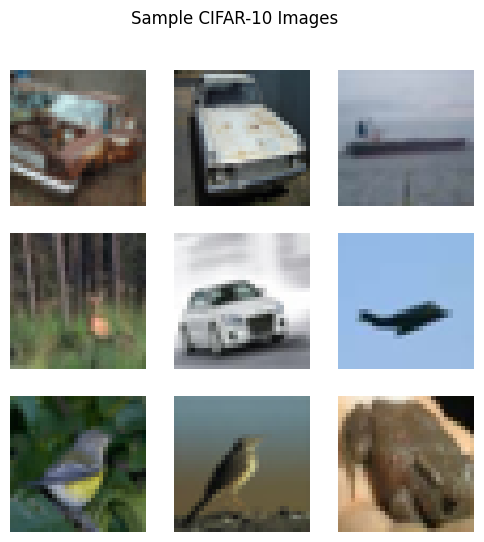

In [5]:
import matplotlib.pyplot as plt

images, labels = next(iter(trainloader))

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].permute(1,2,0))
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.show()

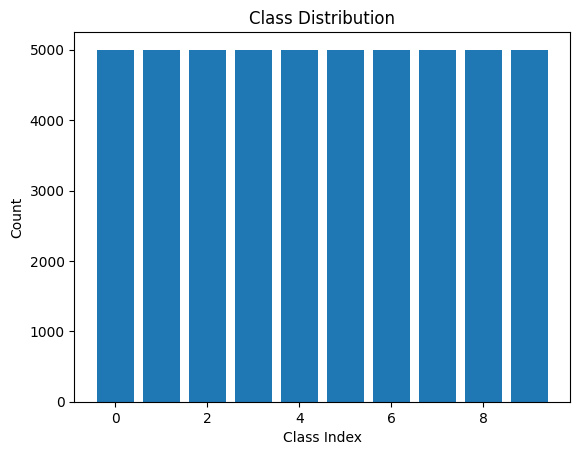

In [7]:
from collections import Counter

labels_list = []
for _, labels in trainloader:
    labels_list.extend(labels.numpy())

counter = Counter(labels_list)

plt.bar(counter.keys(), counter.values())
plt.title("Class Distribution")
plt.xlabel("Class Index")
plt.ylabel("Count")
plt.show()

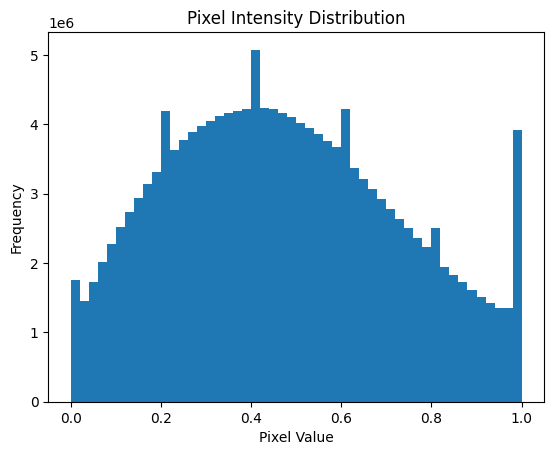

In [9]:
all_pixels = []

for images, _ in trainloader:
    all_pixels.append(images.numpy())

all_pixels = np.concatenate(all_pixels).flatten()

plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

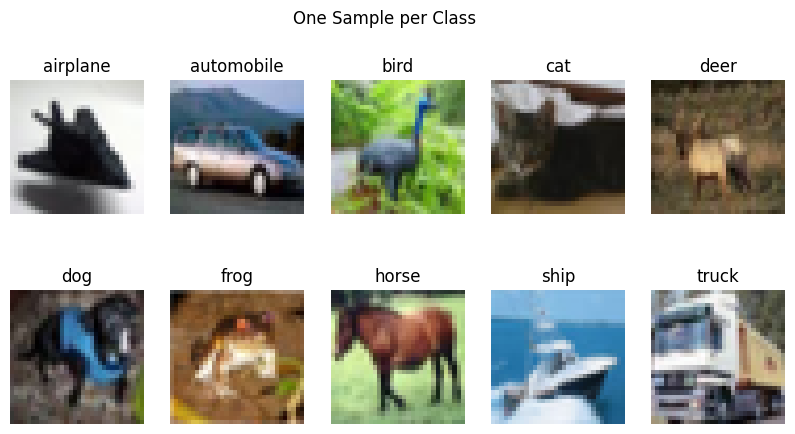

In [10]:
classes = trainset.classes

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, cls in enumerate(classes):
    for img, label in trainset:
        if label == i:
            ax = axes[i//5, i%5]
            ax.imshow(img.permute(1,2,0))
            ax.set_title(cls)
            ax.axis('off')
            break

plt.suptitle("One Sample per Class")
plt.show()

In [11]:
mean = 0.
std = 0.
total_images = 0

for images, _ in trainloader:
    batch_samples = images.size(0)
    images = images.view(batch_samples, images.size(1), -1)

    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_samples

mean /= total_images
std /= total_images

print("Mean:", mean)
print("Std:", std)

Mean: tensor([0.4914, 0.4822, 0.4465])
Std: tensor([0.2023, 0.1994, 0.2010])


In [27]:
def train_model(lambda_val, epochs=10):
    model = Net().to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    loss_history = []

    for epoch in range(epochs):
        model.train()

        total_loss_epoch = 0
        ce_epoch = 0
        sp_epoch = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            classification_loss = criterion(outputs, labels)

            # Sparsity Loss
            sparsity_loss = 0
            for gates in model.get_all_gates():
                sparsity_loss += gates.mean()   

            total_loss = classification_loss + lambda_val * sparsity_loss

            total_loss.backward()
            optimizer.step()

            total_loss_epoch += total_loss.item()
            ce_epoch += classification_loss.item()
            sp_epoch += sparsity_loss.item()

        loss_history.append(total_loss_epoch)

        print(f"Epoch {epoch+1} | Total: {total_loss_epoch:.2f} | CE: {ce_epoch:.2f} | Sparse: {sp_epoch:.2f}")

    return model, loss_history

In [24]:
def evaluate(model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    # Sparsity
    total_weights = 0
    pruned_weights = 0
    threshold = 0.1

    for gates in model.get_all_gates():
        total_weights += gates.numel()
        pruned_weights += (gates < threshold).sum().item()

    sparsity = 100 * pruned_weights / total_weights
    
    avg_gate = 0
    count = 0

    for gates in model.get_all_gates():
        avg_gate += gates.sum().item()
        count += gates.numel()

    avg_gate /= count
    print(f"Average Gate Value: {avg_gate:.4f}")

    return accuracy, sparsity

In [28]:
lambdas = lambdas = lambdas = [5e-3, 1e-2, 2e-2]
results = []

for lam in lambdas:
    print(f"\n🔹 Training with lambda = {lam}")

    model, loss_history = train_model(lam)

    acc, sparsity = evaluate(model)

    print(f"Accuracy: {acc:.2f}%")
    print(f"Sparsity: {sparsity:.2f}%")



🔹 Training with lambda = 0.005
Epoch 1 | Total: 1538.81 | CE: 1533.41 | Sparse: 1079.64
Epoch 2 | Total: 1365.45 | CE: 1360.93 | Sparse: 904.84
Epoch 3 | Total: 1289.97 | CE: 1286.12 | Sparse: 770.21
Epoch 4 | Total: 1242.10 | CE: 1238.73 | Sparse: 673.53
Epoch 5 | Total: 1203.36 | CE: 1200.33 | Sparse: 605.55
Epoch 6 | Total: 1175.36 | CE: 1172.57 | Sparse: 556.60
Epoch 7 | Total: 1155.89 | CE: 1153.29 | Sparse: 519.86
Epoch 8 | Total: 1133.62 | CE: 1131.16 | Sparse: 491.07
Epoch 9 | Total: 1119.59 | CE: 1117.26 | Sparse: 467.57
Epoch 10 | Total: 1103.07 | CE: 1100.83 | Sparse: 447.73
Average Gate Value: 0.3377
Accuracy: 48.11%
Sparsity: 8.14%

🔹 Training with lambda = 0.01
Epoch 1 | Total: 1538.57 | CE: 1527.99 | Sparse: 1057.78
Epoch 2 | Total: 1378.31 | CE: 1369.70 | Sparse: 861.15
Epoch 3 | Total: 1302.38 | CE: 1295.26 | Sparse: 712.49
Epoch 4 | Total: 1253.72 | CE: 1247.63 | Sparse: 608.28
Epoch 5 | Total: 1213.04 | CE: 1207.68 | Sparse: 536.01
Epoch 6 | Total: 1184.32 | CE: 117

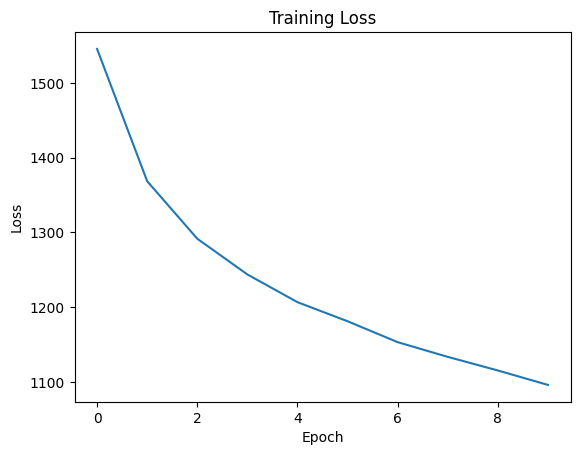

In [30]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [31]:
results = [
    (0.005, 48.11, 8.14),
    (0.01, 48.64, 16.89),
    (0.02, 49.26, 53.76)
]

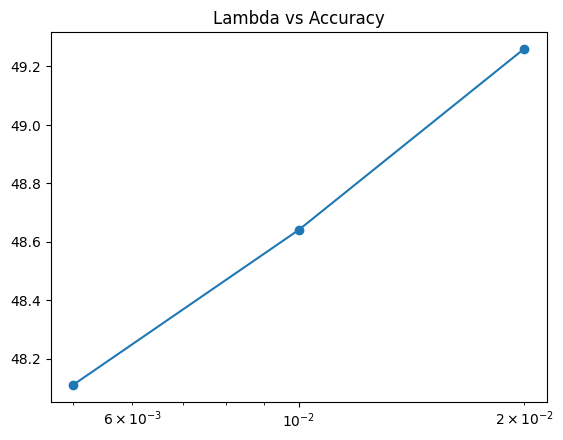

In [32]:
lams = [r[0] for r in results]
accuracies = [r[1] for r in results]

plt.plot(lams, accuracies, marker='o')
plt.xscale('log')
plt.title("Lambda vs Accuracy")
plt.show()

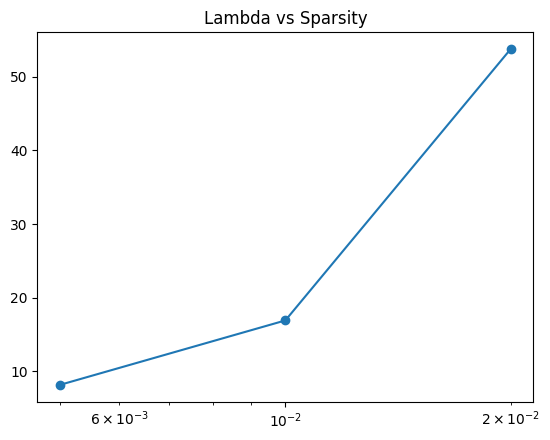

In [33]:
sparsities = [r[2] for r in results]

plt.plot(lams, sparsities, marker='o')
plt.xscale('log')
plt.title("Lambda vs Sparsity")
plt.show()

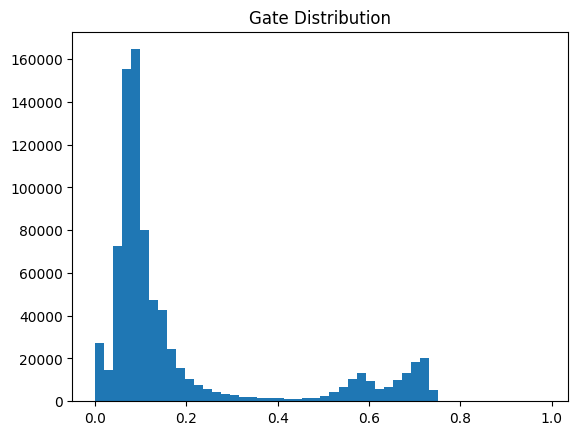

In [34]:
gates = []
for g in model.get_all_gates():
    gates.extend(g.cpu().detach().numpy().flatten())

plt.hist(gates, bins=50)
plt.title("Gate Distribution")
plt.show()